FOWT Farm Overview

Currently, the NREL 5MW wind turbine can be modeled on the OC3 Spar Type floating platform. Wind Speed, Wind Direction, Wave Speed, and Wave direction can all be used through the FOWT_spar_lookupto calculate the 6-dof through the FOWT_spar_lookup module under fowt in the offshore system.

Openfast was used to populate a lookup table with many simulations with varying environmental conditions (wind speed, direction, wave speed, wave direction). Linear interpolation is used for environemental other than those that were simulated. Since  waves naturally cause the floating turbine to rock back and forth, the average position value of the turbine over ~30 seconds, after any displacements from windspeed are taken into account.

The water depth of the lookup table used below is 320 meters. The mooring radius is 853.87 m, and 3 mooring lines are positioned 120 degrees apart.

Minimum wind speed is 4 m/s, minimum wave sig height is 1 m, maximum look up table wind speed is 22 m/s, maximum wave sig height is 7 m. Will be expanded for full 0-25 m/s range, 0-7 wave height. Wave period also to be added at some point in the future, currently, peak spectral period of layered wave is 10 seconds.

The FOWT AEP can be influenced by the number of environmental conditions simulated. 

In [ ]:
sys.path.append(os.path.abspath("."))

from wesl.optimizer.offshore_system.fowt.FOWT_spar_lookup import FOWT_Spar

fowt_example = FOWT_Spar()

print(fowt_example.solve_static_movement(wind_speed=12, wind_direction=60, wave_direction=20, wave_height=7))


ModuleNotFoundError: No module named 'wesl'

The function uses the Pywake coordinate system. Directions use degrees, where 0 degrees is from the North to the South, negative along the y axis. Wind speed is m/s, and wave_height is significant wave height in meters.

The returned values are: X displacement, Y displacement, Z displacement, and turbine tilt. Displacements are all meters, while tilt is in degrees. The other 2 degrees of freedom can also be accessed, but they are not currently used in any analysis.

We can visualize how the wind turbine is displaced under different wind speeds and directions.

Placing wind speeds in increasing order of displacements, we get the following sequence: [4, 7, 22, 18, 14, 11] in m/s.
The displacement is based on the turbine thrust, which is reach maximum at ~11.5 m/s.
Thrust curve of NREL5MW: https://www.researchgate.net/figure/The-wind-thrust-curve-of-the-NREL-5-MW-wind-turbine-with-different-wind-velocities-in_fig4_284227317

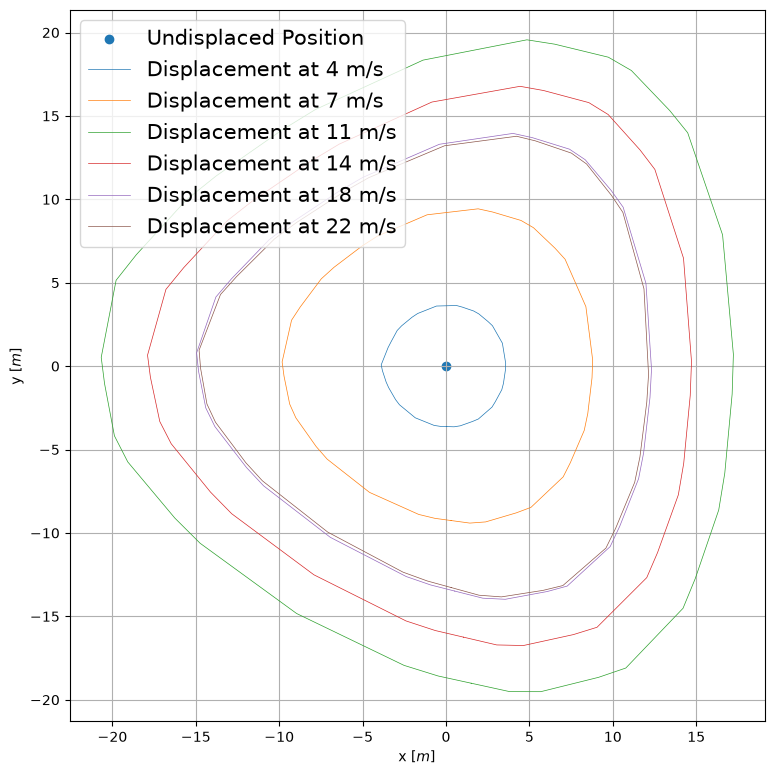

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

wind_speeds = np.linspace(4, 22, 6, endpoint=True, dtype = int)
wind_directions = np.linspace(0, 360, 60, endpoint=True, dtype = int)

displaced_x = np.zeros((len(wind_speeds), len(wind_directions)))
displaced_y = np.zeros((len(wind_speeds), len(wind_directions)))

# for each given wind directions and speed record FOWT displacement for plotting
  
for ws_index in range(len(wind_speeds)):
    for wd_index in range(len(wind_directions)):
        x_new, y_new, z_new, tilt_new = fowt_example.solve_static_movement(wind_speeds[ws_index],wind_directions[wd_index], wave_direction=0, wave_height=0)
        displaced_x[ws_index, wd_index] = x_new
        displaced_y[ws_index, wd_index] = y_new

# standard matplotlib figure
plt.figure(figsize=(8,8))
plt.plot()

# show center position
plt.scatter(0,0, label = "Undisplaced Position")

#plot displacementds
for ws_index in range(len(wind_speeds)):
        x, y = displaced_x[ws_index,:], displaced_y[ws_index,:]
        color = ws_index / len(wind_speeds)
        plt.plot(x, y,linewidth=0.5, label = f"Displacement at {wind_speeds[ws_index]} m/s")

plt.rcParams.update({'font.size': 15})
plt.xlabel('x [$m$]')
plt.ylabel('y [$m$]')
plt.legend()
plt.tight_layout()
plt.axis('equal')
plt.grid(True)


There is also an openMDAO component that can handle optimization of FOWT wind farms. The exact layout of the component is still WIP, however it is fully functional with non-gradient based optimizers. See the example below for usage.

/home/silver/anaconda3/envs/test_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/silver/anaconda3/envs/test_env/lib/python3.11/site-packages/openmdao/core/system.py:3628: OpenMDAOWarning:<class Group>: Constraint 'Spacing_Constraint.spacing_violation' requires one of arguments 'lower', 'upper', or 'equals' to be specified.
/home/silver/anaconda3/envs/test_env/lib/python3.11/site-packages/openmdao/core/group.py:1197: DerivativesWarning:Constraints or objectives [floating_wind_farm.AEP] cannot be impacted by the design variables of the problem because no partials were defined for them in their parent component(s).


done
Entered compute fixedbottomcomponent


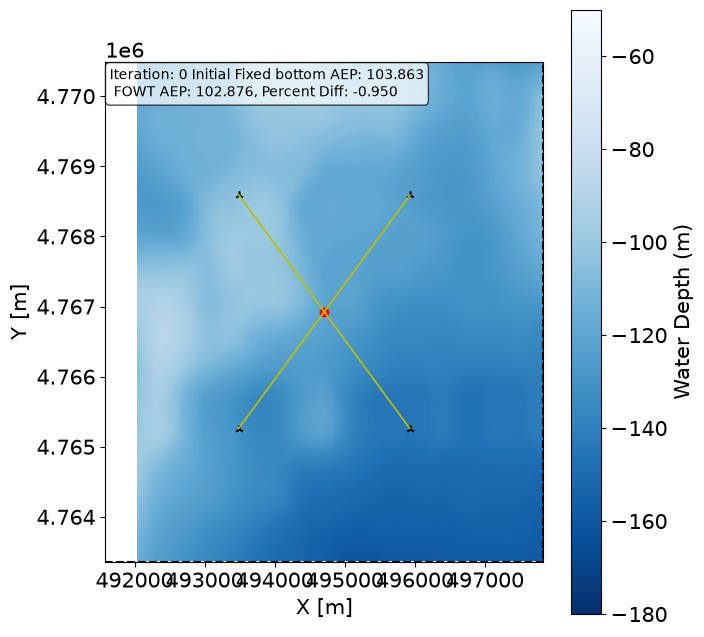

total time for compute cycle: 3.214208562974818 seconds
Entered compute fixedbottomcomponent


<Figure size 640x480 with 0 Axes>

total time for compute cycle: 2.3631914489669725 seconds
Entered compute fixedbottomcomponent


/home/silver/anaconda3/envs/test_env/lib/python3.11/site-packages/scipy/_lib/pyprima/common/preproc.py:68: UserWarning: COBYLA: Invalid MAXFUN; it should be at least num_vars + 2; it is set to 10
  warn(f'{solver}: Invalid MAXFUN; it should be at least {min_maxfun_str}; it is set to {maxfun}')


<Figure size 640x480 with 0 Axes>

...

total time for compute cycle: 2.552700716012623 seconds
Entered compute fixedbottomcomponent


<Figure size 640x480 with 0 Axes>

total time for compute cycle: 2.4999986400362104 seconds
Entered compute fixedbottomcomponent


<Figure size 640x480 with 0 Axes>

total time for compute cycle: 3.0171851420309395 seconds
Optimization FAILED.
Return from COBYLA because the objective function has been evaluated MAXFUN times.
-----------------------------------


In [ ]:
# # WESL imports
from wesl.optimizer.constraints.wind_farm_constraints import BoundaryConstraint, PairWiseSpacing
from wesl.optimizer.offshore_system.wind_system import FloatingBottomWindFarm

# # WESL optimizer external dependencies
import numpy as np
import openmdao.api as om
from IPython.display import display

from pathlib import Path

 
# AEP Calculator: PyWake Dependencies
from py_wake.literature.gaussian_models import Bastankhah_PorteAgel_2014
from wesl.utils.plot import get_water_depth_map
from py_wake.literature.cumulative_sum import nrel5mw

from multiprocessing import freeze_support, set_start_method

from pyproj import Transformer

from py_wake.site._site import UniformWeibullSite

from wesl.optimizer.offshore_system.fowt.FOWT_spar_lookup import wave_site

class Maine_test(UniformWeibullSite): # Double-check: plot the wind rose
    def __init__(self, ti=0.07, shear=None):
        f = [8.37, 6.83, 5.38, 4.77, 4.10, 4.80,
            8.22, 13.29, 11.22, 10.14, 11.72, 11.16]
        a = [10.00, 10.29, 9.87, 10.22, 10.01, 9.09,
            11.19, 12.11, 10.65, 10.84, 11.68, 10.89]
        k = [2.241, 1.804, 1.849, 2.086, 1.871, 1.677,
            2.163, 2.836, 2.545, 2.405, 2.489, 2.587]
        UniformWeibullSite.__init__(self, np.array(f) / np.sum(f), a, k, ti=ti, shear=shear)
        self.name = "Maine Wind Farm"

# dummy site, get real data when possible

class test_site(wave_site):
    def __init__(self):
        wave_f = np.array([8.37, 6.83, 5.38, 4.77, 4.10, 4.80])
        wave_k = np.array([2.971, 2.971, 2.971, 2.971, 2.971, 2.971])
        wave_a = np.array([2.027, 2.027, 2.027, 2.027, 2.027, 2.027])
        wave_site.__init__(self, f=wave_f / sum(wave_f),a=wave_a,k=wave_k)

# IMPORTANT: make sure to set up code in function. This will make sure parallel processing in floating wind farm will function correctly.
# This is a by product of python multiprocessing and parrallelism

def fowt_farm(n_turbine):
    test_wave_site = test_site()

    # Get turbine positions, depth map, etc like fixed bottom
    # Change n_turbine here, positions will be evaluated automatically
    # The exact method of aquiring x and y coordinates doesnt matter
    # just make sure they are euclidean


    # long/lat coordinates for water depth map
    min_lon, max_lon, min_lat, max_lat = -69.1, -68.85, 43.02, 43.15

    # This will get the water depth map background, purely visual at this time

    water_depth_map_params = get_water_depth_map(water_depth_data=f"maine/maine_data.nc",
                                                min_lon = min_lon,
                                                max_lon = max_lon,
                                                min_lat = min_lat,
                                                max_lat = max_lat)


    ###########################################
    # This block will just determine the x-y coordinates of each turbine in the farm
    # number is determined by n_turbine
    
    rows = int(np.ceil(np.sqrt(n_turbine)))
    columns =  int(np.ceil(n_turbine / rows))

    # Change this value for denser farms. Spacing is in longitude/latitude
    spacing = 0.015

    x_coordinates = np.linspace(min_lon+0.02, min_lon+0.02+spacing*columns, columns)
    y_coordinates = np.linspace(min_lat+0.02, min_lat+0.02+spacing*rows, rows,)


    x_coordinates, y_coordinates = np.meshgrid(x_coordinates, y_coordinates)

    x_coordinates = x_coordinates.flatten()
    y_coordinates = y_coordinates.flatten()

    # values are converted to euclidean coordinates, make sure the coordinate systems work for your farm location
    transformer = Transformer.from_crs("EPSG:4326", "EPSG:32619", always_xy=True)
    x_coordinates, y_coordinates = transformer.transform(x_coordinates, y_coordinates)

    x_coordinates = x_coordinates.flatten()
    y_coordinates = y_coordinates.flatten()

    x_coordinates = x_coordinates[:n_turbine]
    y_coordinates = y_coordinates[:n_turbine]
    #############################################
    
    # Define Boundary of wind farm
    x_boundary = [int(np.min(x_coordinates) - 1900), int(np.max(x_coordinates) + 1900)]
    y_boundary = [int(np.min(y_coordinates) - 1900), int(np.max(y_coordinates) + 1900)]

    boundary = np.array([
        [int(x_boundary[0]), int(y_boundary[0])],
        [int(x_boundary[1]), int(y_boundary[0])],
        [int(x_boundary[1]), int(y_boundary[1])],  
        [int(x_boundary[0]), int(y_boundary[1])]   
    ])


    # lookup model turbine is currently just nrel5mw, so wind_turbines must be set accordingly
    wind_turbines = nrel5mw()
    
    # define pywake site
    site = Maine_test() 
    sim_res = Bastankhah_PorteAgel_2014(site,                 
                                        wind_turbines, 
                                        k=0.0324555)
    
    
    aep_init = sim_res(x_coordinates, y_coordinates).aep().sum() 

    # create openmdao problem
    prob = om.Problem()

    # create floating wind farm
    prob.model.add_subsystem('floating_wind_farm', 
                            FloatingBottomWindFarm(layout_coordinates = np.array([x_coordinates,
                                                                                y_coordinates]),
                                                sim_res = Bastankhah_PorteAgel_2014(site, 
                                                                                    wind_turbines, 
                                                                                    k=0.0324555), 
                                                boundary = boundary, 
                                                lon_grid_fine = water_depth_map_params[0],
                                                lat_grid_fine = water_depth_map_params[1],
                                                interpolated_elevation = water_depth_map_params[2],
                                                plot_lim = np.array(x_boundary + y_boundary),
                                                aep_init = aep_init,         
                                                num_cores = 5,      # num of cores for parallelizing. 
                                                                    # Jupyter notebook may not parallelize correctly. If you find errors in this file, try setting cores to 1 
                                                using_slurm = False,         # if using slurm, this will correctly parallelize, if this is incorrectly set, your optimization might be much slower 
                                                wave_site = test_wave_site   # use test wave site from before
                                                ),
                            promotes_inputs=['x', 'y'])

    # set inter turbine spacing constraints
    prob.model.add_subsystem('Spacing_Constraint', 
                            PairWiseSpacing(n_turbines = n_turbine, 
                                            min_spacing = 3*wind_turbines.diameter()), 
                            promotes_inputs=['x', 'y'])

    # set boundary constraints
    prob.model.add_subsystem('Boundary_Constraint',
                            BoundaryConstraint(polygon_vertices = boundary,
                                                number_of_turbines = n_turbine),
                            promotes_inputs=['x','y']
    )

    # Driver setup
    prob.driver = om.ScipyOptimizeDriver(tol = 1e-9)
    prob.driver.options['optimizer'] = 'COBYLA'  # cobyla has best performance
    
    # to use SLSQP, comment out line above, and uncomment the following two:
    
    # prob.driver.options['optimizer'] = 'SLSQP'
    # prob.model.approx_totals(method='fd', step=1e-6, form='forward')
    
    
    prob.driver.options['maxiter'] = 2 # set this higher on real optimization
    prob.driver.options['disp'] = False

    # Input defaults
    prob.model.set_input_defaults('x', x_coordinates)
    prob.model.set_input_defaults('y', y_coordinates)

    # Design variables
    prob.model.add_design_var('x', 
                            lower=min(boundary[:,0]), 
                            upper=max(boundary[:,0]), 
                            scaler=0.01)

    prob.model.add_design_var('y', 
                            lower=min(boundary[:,1]), 
                            upper=max(boundary[:,1]), 
                            scaler=0.01)

    # Objective function
    prob.model.add_objective('floating_wind_farm.AEP',  scaler=0.01)

    # Setting constraints
    prob.model.add_constraint('Spacing_Constraint.spacing_violation', scaler=0.01)
    prob.model.add_constraint('Boundary_Constraint.boundary_cons', upper=0.0) 

    prob.setup()

    prob.run_driver()

    prob.cleanup()

# to properly parallelize, format the optimization you wish to run like below
# put main function after "freeze_support()" and "set_start_method('fork')"
if __name__ == '__main__':
    freeze_support()
    set_start_method('fork') # ipynb kernal may need to be restarted if you try to run this line twice, only an issue with jupyter notebook 
    # run with 4 turbines
    fowt_farm(4)



/home/silver/anaconda3/envs/test_env/lib/python3.11/site-packages/openmdao/core/system.py:3628: OpenMDAOWarning:<class Group>: Constraint 'Spacing_Constraint.spacing_violation' requires one of arguments 'lower', 'upper', or 'equals' to be specified.
/home/silver/anaconda3/envs/test_env/lib/python3.11/site-packages/openmdao/core/group.py:1197: DerivativesWarning:Constraints or objectives [floating_wind_farm.AEP] cannot be impacted by the design variables of the problem because no partials were defined for them in their parent component(s).


done
Entered compute fixedbottomcomponent


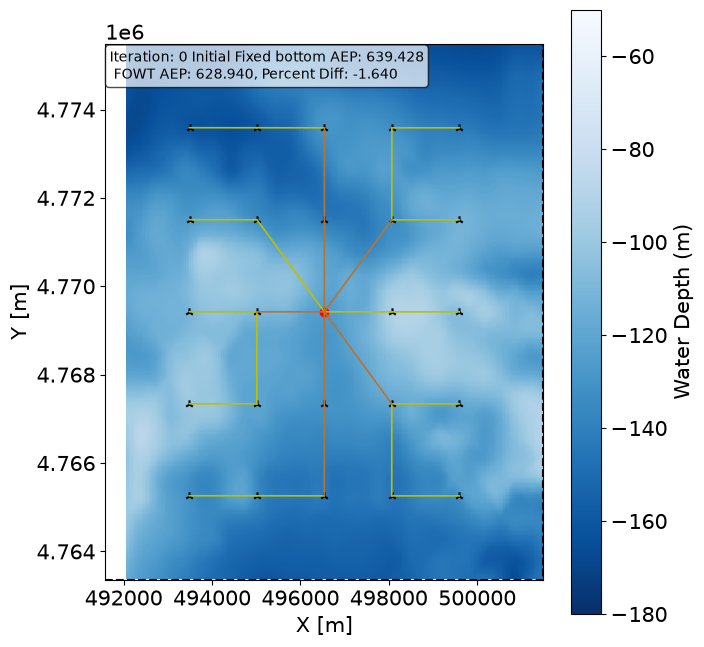

total time for compute cycle: 15.90812924405327 seconds
Entered compute fixedbottomcomponent


<Figure size 640x480 with 0 Axes>

total time for compute cycle: 14.594347373000346 seconds
Entered compute fixedbottomcomponent


/home/silver/anaconda3/envs/test_env/lib/python3.11/site-packages/scipy/_lib/pyprima/common/preproc.py:68: UserWarning: COBYLA: Invalid MAXFUN; it should be at least num_vars + 2; it is set to 52
  warn(f'{solver}: Invalid MAXFUN; it should be at least {min_maxfun_str}; it is set to {maxfun}')


<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

total time for compute cycle: 16.512831025989726 seconds
Entered compute fixedbottomcomponent


<Figure size 640x480 with 0 Axes>

total time for compute cycle: 16.601404678018298 seconds
Entered compute fixedbottomcomponent


KeyboardInterrupt: 

In [ ]:
# example with more turbines
if __name__ == '__main__':
    # run with 20 turbines
    fowt_farm(25)